In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
from transformers import GPT2Model

# get the Word Position Embeddings matrix
gpt2 = GPT2Model.from_pretrained('gpt2')
positions = gpt2.wpe.weight.detach().numpy()

/opt/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/anaconda3/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [ ]:
# visualize the matrix
plt.figure(figsize=(10,4))
plt.imshow(positions.T,aspect='auto',vmin=-.2,vmax=.2)
plt.gca().set(xlabel='Token position',ylabel='Dimensions',title='GPT-2 position embedding matrix')
plt.show()

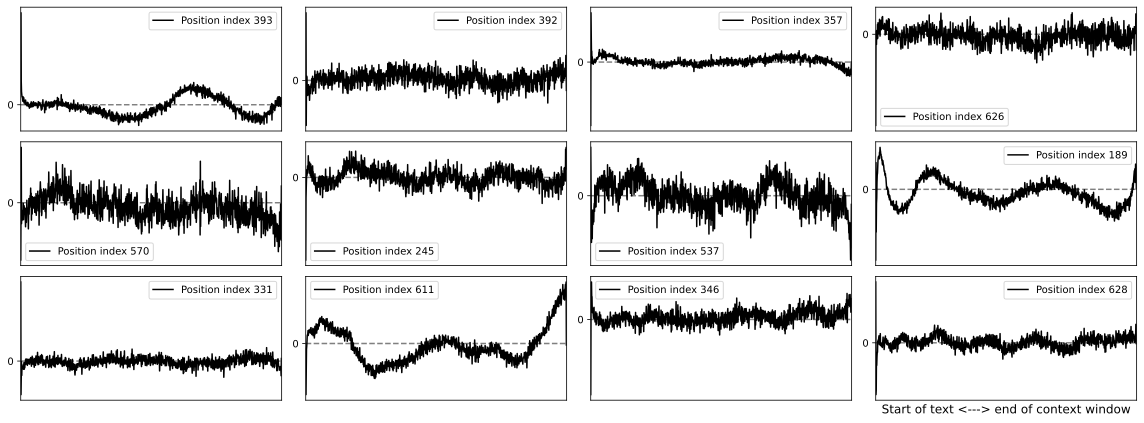

In [9]:
_,axs = plt.subplots(3,4,figsize=(16,6))

# pick random vectors
for a in axs.flatten():

  # a random position embedding vector
  randidx = np.random.randint(positions.shape[1])

  # and plot it
  a.plot(positions[:,randidx],'k',label=f'Position index {randidx}')
  a.axhline(0,linestyle='--',color='gray',zorder=-3)

  a.set(xticks=[],yticks=[0],xlim=[0,positions.shape[0]])
  a.legend(fontsize=10)


# x-axis label on one plot
a.set_xlabel('Start of text <---> end of context window',fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# copied from "embed_positionEmbeddings.ipynb"

# cosine similarities for "time series" (token index)
Pnorm1 = positions / np.linalg.norm(positions,axis=1,keepdims=True)
cossim_tokens = Pnorm1 @ Pnorm1.T

# cosine similarities across embedding dimensions
Pnorm0 = positions / np.linalg.norm(positions,axis=0,keepdims=True)
cossim_embeds = Pnorm0.T @ Pnorm0

In [ ]:
# draw the images (also copied from previous code file)
fig,axs = plt.subplots(1,2,figsize=(12,5))

h = axs[0].imshow(cossim_tokens,vmin=-1,vmax=1)
axs[0].set(xlabel='Token index ("time")',ylabel='Token index ("time")',title='$S_c$ over "time"')
ch = fig.colorbar(h,ax=axs[0],pad=.02,fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

h = axs[1].imshow(cossim_embeds,vmin=-1,vmax=1)
axs[1].set(xlabel='Embedding index',ylabel='Embedding index',title='$S_c$ across embeddings')
ch = fig.colorbar(h,ax=axs[1],pad=.02,fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

plt.tight_layout()
plt.show()

In [ ]:
# small demo about triu:
A = np.random.randint(0,9,(4,4))
print(A)
print('')
A[np.nonzero(np.triu(A,1))]

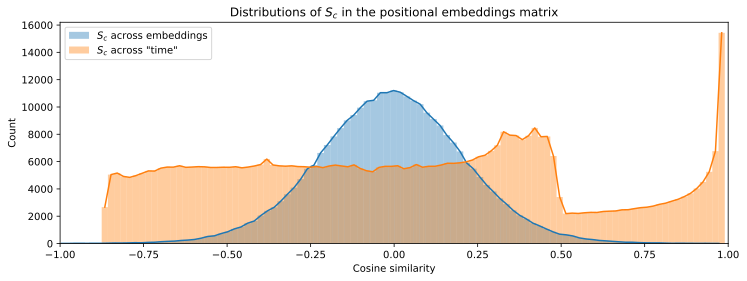

In [6]:
# get the unique cosine similarity values from the upper-triangle
unique_cs_embeds = cossim_embeds[np.nonzero(np.triu(cossim_embeds,1))] # note the ",1" to avoid the trivial diagonal
unique_cs_tokens = cossim_tokens[np.nonzero(np.triu(cossim_tokens,1))]

# get their distributions
embed_hy,embed_hx = np.histogram(unique_cs_embeds,100)
token_hy,token_hx = np.histogram(unique_cs_tokens,100)

# visualize!
plt.figure(figsize=(12,4))
plt.bar(embed_hx[:-1],embed_hy,width=np.diff(embed_hx[:2]),alpha=.4,label='$S_c$ across embeddings')
plt.bar(token_hx[:-1],token_hy,width=np.diff(token_hx[:2]),alpha=.4,label='$S_c$ across "time"')
plt.plot(embed_hx[:-1],embed_hy)
plt.plot(token_hx[:-1],token_hy)

plt.legend()
plt.gca().set(xlim=[-1,1],xlabel='Cosine similarity',ylabel='Count',title='Distributions of $S_c$ in the positional embeddings matrix')
plt.show()